# Multivariate Data Analysis

## Learning goals
- Compare two variables with simple plots and tests.
- Interpret the code for a basic association between variables.
- How to work with multiple variables with linear regression models.
- Save figures for later use.


---

## 0) Load libraries and modules (again) and set up folders

Each notebook runs in its own independent environment. This means that any libraries you load, variables you create, or settings you modify are available only within that notebook.

For this reason, it is important to start each notebook by loading the required packages and setting up the folder structure needed for the analysis. Keeping your work organized makes it easier to reproduce your results, share your code with others, and revisit the project in the future.


In [3]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf

if not pathlib.Path("figures").exists:
    pathlib.Path("figures").mkdir()

    sns.set_theme(style="whitegrid", context="notebook")

---
## 1) Load the data
 This time we are going to access the path to the file directly using `pathlib`.


In [7]:
file_path = pathlib.Path("..","Day_2", "penguins_clean.csv")
df = pd.read_csv(file_path)

for col in ["row_id","species","island", "sex", "observation_year"]:
    df[col] = df[col].astype("category")
    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   row_id             333 non-null    category
 1   species            333 non-null    str     
 2   island             333 non-null    str     
 3   bill_length_mm     333 non-null    float64 
 4   bill_depth_mm      333 non-null    float64 
 5   flipper_length_mm  333 non-null    float64 
 6   body_mass_g        333 non-null    float64 
 7   sex                333 non-null    str     
 8   observation_year   333 non-null    int64   
dtypes: category(1), float64(4), int64(1), str(3)
memory usage: 29.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   row_id             333 non-null    category
 1   species            333 non-null    category
 2   is

---
## 2) Compare two or more variables

Before we start testing hypothesis, it is good to have a grasp of how our data behaves. Usually, after cleaning our data and check for missing values and inconcistencies, we explore it using different kinds of plots.
We will first set a few differnt variable that we are going to explore according to their data type or their role in our analysis.

In [8]:
# Set column names for analysis. Replace the defaults if you want to explore different variables.
quantitative_x = "bill_length_mm"
quantitative_y = "bill_depth_mm"
group_column = "species"
outcome_column = "body_mass_g" #numerical
group_a = "Adelie"
group_b = "Chinstrap"

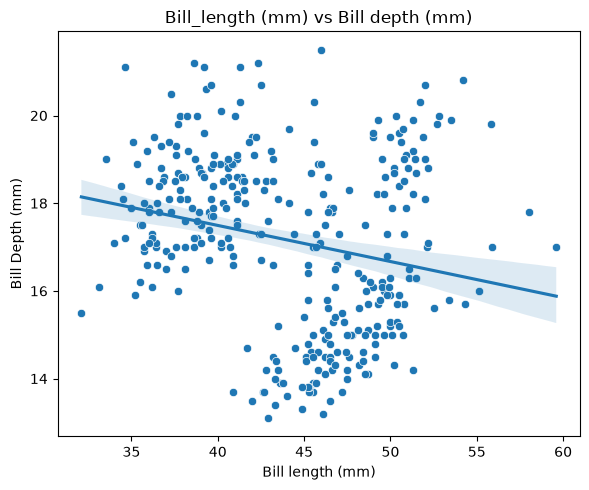

In [22]:
fig, ax = plt.subplots(figsize = (6,5))
sns.scatterplot(data=df, x=quantitative_x, y= quantitative_y, ax= ax)
sns.regplot(data=df, x=quantitative_x, y= quantitative_y, scatter = False, ax = ax)
ax.set_title("Bill_length (mm) vs Bill depth (mm)")
ax. set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill Depth (mm)")
plt.tight_layout()
plt.savefig("two_variables_scatterplot.png", dpi = 300)
plt.show()

---
### Comparing multiple variables
#### PCA (Principal Component Analysis) — overview
PCA summarizes the main directions of variability in multiple numeric variables. In this lecture we focus on using PCA as a practical tool in Python:
- Choose numeric variables that are meaningful for the question.
- Check correlations and data quality before running PCA.
- Standardize variables so that scale differences do not dominate the results.
- Run PCA and inspect how much variance each principal component explains.
- Visualize the first two components and color points by a categorical variable (e.g., species) to help interpret patterns.

Run the following cells step-by-step and read the printed outputs before continuing.

### Check pairwise relationships (correlation matrix)

Before running PCA, inspect the correlation matrix of the numeric variables. PCA finds directions of combined variability — if variables are uncorrelated and have very different scales, PCA results may be harder to interpret.
Also, this is the part you need to have a good idea about data type and what your are looking. Luckly we already took care of it.

In [24]:
numeric_cols = df.select_dtypes(float).columns.tolist()
print(numeric_cols)

corr = df[numeric_cols].corr()
print("Correlation matirx (rounded)")
print(corr.round(2))

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Correlation matirx (rounded)
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


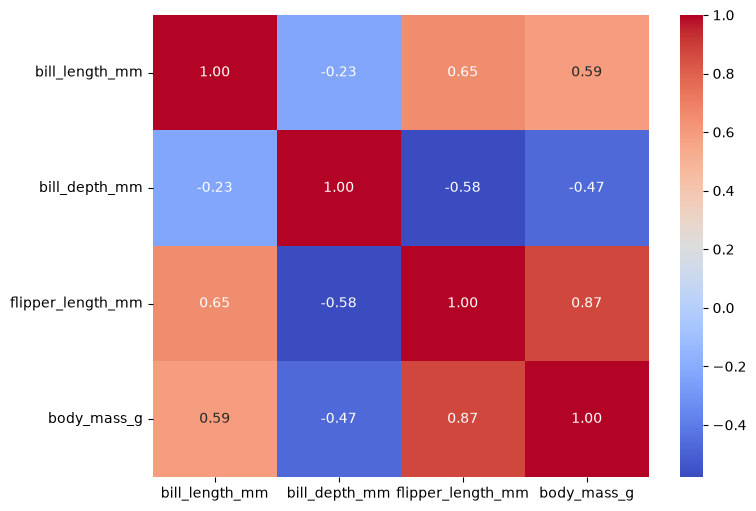

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot = True, fmt=".2f", cmap="coolwarm",cbar = True)
plt.savefig("correlation_matrix_heatmap.png", dpi = 300) 
plt.show()

### Prepare data for PCA
PCA requires numeric values and no missing values. A common simple approach is to drop rows with missing values only in the numeric columns used for PCA. We will standardize the variables (zero mean, unit variance) before running PCA so that variables measured on different scales contribute equally.

In [30]:
display(df[numeric_cols].head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


In [33]:

    ###Reminder: PCA cant handle missing values, so important to compute them

pca_df = df[numeric_cols].dropna() 

X = StandardScaler().fit_transform(pca_df)

print(X)

[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 ...
 [ 1.02687621  0.52644436 -0.56928439 -0.53738048]
 [ 1.24663828  0.93330475  0.64546078 -0.13315457]
 [ 1.13675725  0.7807321  -0.2120064  -0.53738048]]


### Run PCA and examine explained variance
We run PCA keeping two components for visualization. The `explained_variance_ratio_` shows the fraction of the total variance captured by each principal component — this helps judge whether a low-dimensional summary is informative.

In [39]:
pca = PCA(n_components = 2)
pcs = pca.fit_transform(X)
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("PCA feature names:", pca_df.columns.tolist() )

Explained variance ratio (PC1, PC2): [0.68633893 0.19452929]
PCA feature names: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


### Plot PC1 vs PC2
We create a small plotting dataframe with `PC1` and `PC2` coordinates and attach simple metadata (species, sex) if available, so students can color points by species to see whether species separate along the principal components.

<Axes: xlabel='PC1', ylabel='PC2'>

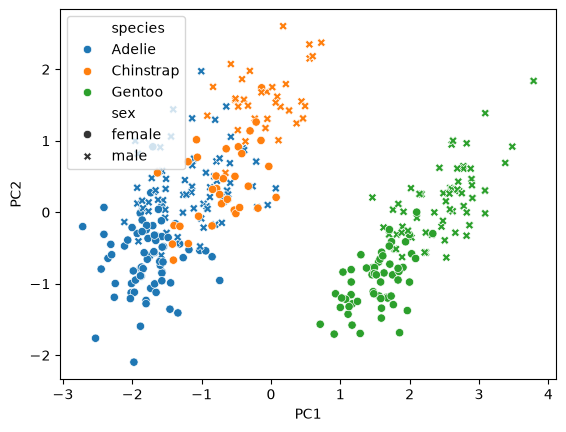

In [40]:
plot_df = pd.DataFrame(pcs, columns = ["PC1","PC2"], index = pca_df.index)
for meta in ("species", "sex"):
    if meta in df.columns:
        plot_df[meta] = df.loc[plot_df.index, meta].values

hue = "species"
style = "sex"
sns.scatterplot(data=plot_df, x="PC1", y= "PC2", hue = hue, style = style)

## Formatting numbers with f-strings

When presenting results, like our previous PCA, it is important to control how numbers are displayed. Raw numerical output often contains too many decimal places or is difficult to read. Python's **f-strings** provide a simple and flexible way to format values directly within text, making notebooks, reports, and plots more professional and easier to interpret.

The general syntax is:

```python
value = 3.14159265
print(f"The value is {value:.2f}")
```

Output:

```text
The value is 3.14
```
When you write `f`before the beggining for your string, you allow it to take objects between curly braces, making it easier to write messages.
The part after the colon and dot (`:.`) controls how the value is displayed.

### Fixed-point notation (`.f`)

Use `f` to display a specific number of decimal places.

```python
pi = 3.14159265

print(f"{pi:.1f}")
print(f"{pi:.4f}")
```

Output:

```text
3.1
3.1416
```

This format is useful for summary statistics such as means and standard deviations.

### Scientific notation (`.e`)

Scientific notation is particularly useful for very large or very small values.

```python
x = 0.000012345

print(f"{x:.2e}")
```

Output:

```text
1.23e-05
```

Common in omics and statistical analyses when displaying p-values or concentrations.

### General format (`.g`)

The `g` format automatically chooses between fixed-point and scientific notation depending on the magnitude of the number.

```python
x = 0.000012345
y = 12345

print(f"{x:.3g}")
print(f"{y:.3g}")
```

Output:

```text
1.23e-05
1.23e+04
```

This format is useful when you want compact output without deciding in advance which notation to use.

### Formatting percentages

Percentages are commonly used when reporting proportions or missing values.

```python
missing_fraction = 0.1234

print(f"{missing_fraction:.1%}")
```

Output:

```text
12.3%
```
#### The list of goes on [here](https://www.w3schools.com/python/python_string_formatting.asp).

### Before moving on
Let's improve our previous plot.


---
## 3) Testing and modelling

In this section, we will perform some basic statistical tests and build simple models. Along the way, we will also learn how to use `print()` and string formatting to present results in a more readable and professional way.

### A very brief recap of statistical tests and models

This is not a statistics course, but it is useful to review a few key concepts.

**Statistical tests**, such as the *t-test* and the *Mann-Whitney U test*, help us determine whether there is statistical evidence that two groups differ from one another. These methods are often used to compare measurements collected from different experimental groups.

**Statistical models** are used to describe and quantify relationships between variables. They allow us to investigate how one or more variables influence an outcome of interest.

One of the simplest and most widely used statistical models is the **linear model**, which assumes a linear relationship between predictors and the outcome variable. Although simple, linear models provide a powerful framework for understanding patterns in data and form the basis for many more advanced analytical methods.

---
## Further reading
You can further explore how to plot, test hypothesis, make models exploring the libraries documentations.

---
## What comes next?

Next class (`Day_4`) we will discuss about reproducible science and how to keep track of changes when writting our own scripts, notebooks, workflows, or anything. Follow the class using `Reproducible_science.md` 